In [ ]:
# Connecting API w/ Kaggle

import os

os.environ['KAGGLE_USERNAME'] = "XXXXXXXXXXXXXXXX"
os.environ['KAGGLE_KEY'] = "XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX"



In [ ]:
#Downloading the dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

!unzip -q chest-xray-pneumonia.zip
print("Dados descompactados e prontos!")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.27G/2.29G [00:22<00:00, 107MB/s] 
100% 2.29G/2.29G [00:22<00:00, 107MB/s]
Dados descompactados e prontos!


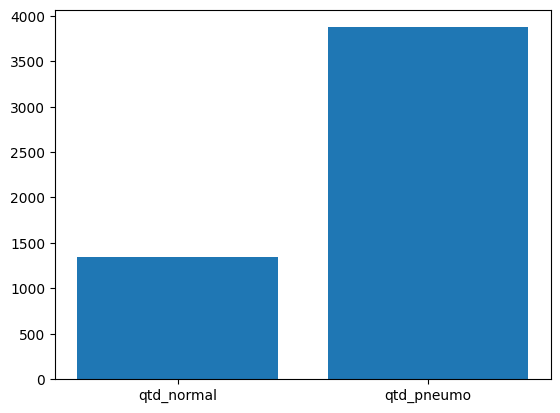

In [ ]:

# EDA

import matplotlib.pyplot as plt

train_dir = 'chest_xray/train'
normal_dir = os.path.join(train_dir, 'NORMAL')
pneumo_dir = os.path.join(train_dir, 'PNEUMONIA')

qtd_normal = len(os.listdir(normal_dir))
qtd_pneumo = len(os.listdir(pneumo_dir))

plt.bar(["qtd_normal", "qtd_pneumo"], [qtd_normal, qtd_pneumo])
plt.show()


(np.float64(-0.5), np.float64(1039.5), np.float64(759.5), np.float64(-0.5))

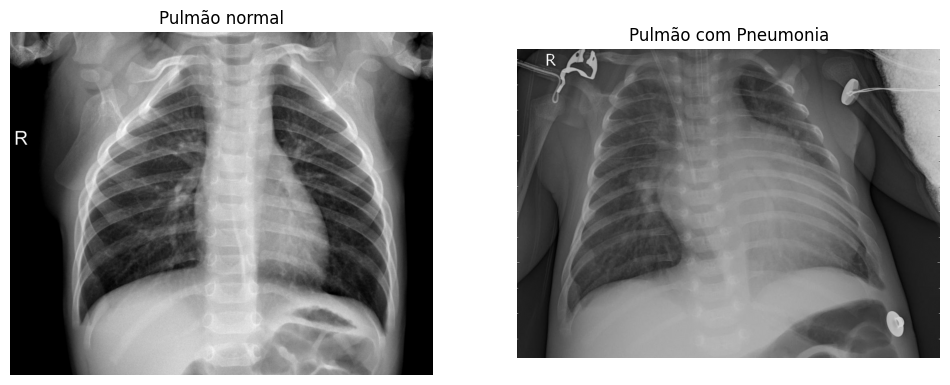

In [ ]:

import matplotlib.image as mpimg
import random

# randomly picking an image from each category
normal_img_name = random.choice(os.listdir(normal_dir))
pneumo_img_name = random.choice(os.listdir(pneumo_dir))

img_normal = mpimg.imread(os.path.join(normal_dir, normal_img_name))
img_pneumo = mpimg.imread(os.path.join(pneumo_dir, pneumo_img_name))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_normal, cmap='gray')
axes[0].set_title('Pulmão normal')
axes[0].axis('off')

axes[1].imshow(img_pneumo, cmap='gray')
axes[1].set_title('Pulmão com Pneumonia')
axes[1].axis('off')



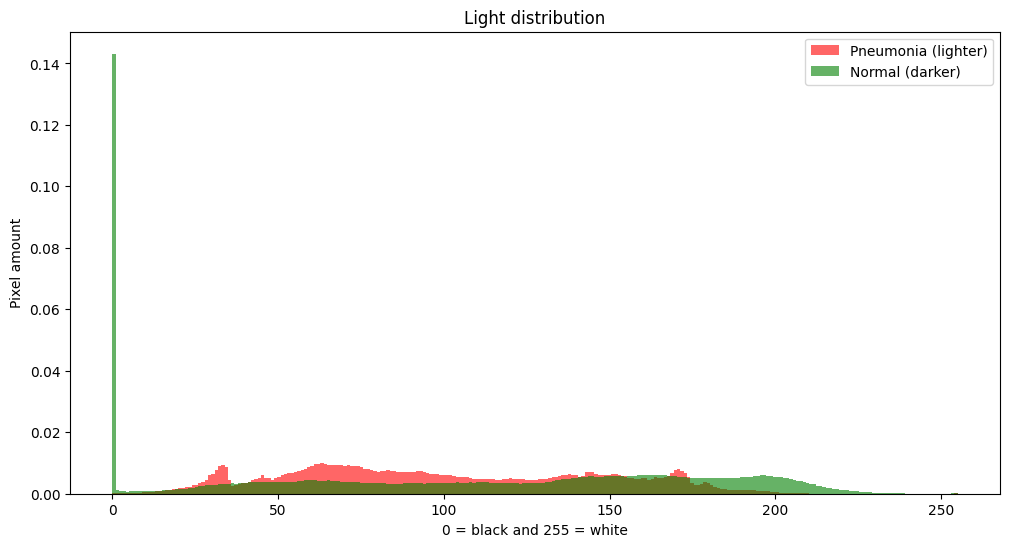

In [ ]:
import cv2

img_n_cv2 = cv2.imread(os.path.join(normal_dir, normal_img_name), cv2.IMREAD_GRAYSCALE)
img_p_cv2 = cv2.imread(os.path.join(pneumo_dir, pneumo_img_name), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12,6))

# Density = true because images have different sizes
plt.hist(img_p_cv2.ravel(), bins=256, color='red', alpha=0.6, density=True, label='Pneumonia (lighter)')
plt.hist(img_n_cv2.ravel(), bins=256, color='green', alpha=0.6, density=True, label='Normal (darker)')

plt.legend()
plt.title('Light distribution')
plt.xlabel('0 = black and 255 = white')
plt.ylabel('Pixel amount')
plt.show()

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_tranforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

tests_tranforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

tests_dir = 'chest_xray/test'

train_data = datasets.ImageFolder(train_dir, transform=train_tranforms)
tests_data = datasets.ImageFolder(tests_dir, transform=tests_tranforms)

BATCH_SIZE = 32

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
tests_loader = DataLoader(tests_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total number of batches for training: {len(train_loader)}")
print(f"Classes found: {train_data.classes}")

Total number of batches for training: 163
Classes found: ['NORMAL', 'PNEUMONIA']


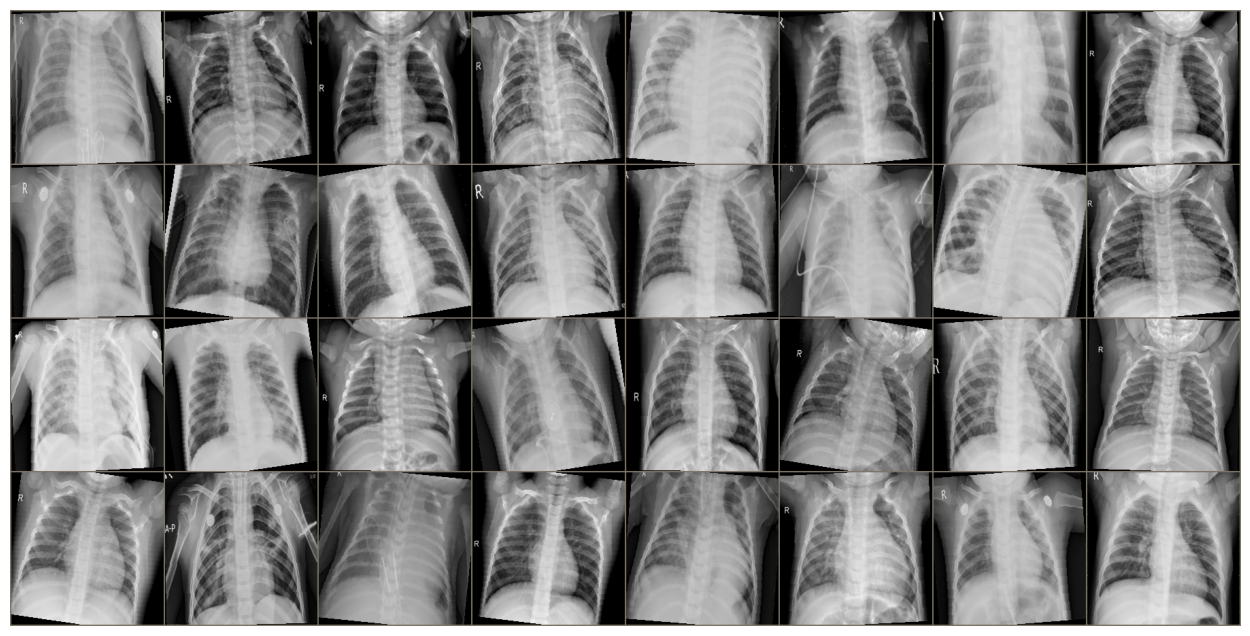

In [ ]:
#Looking at the batch

import torchvision
import numpy as np
import matplotlib.pyplot as plt

images, labes = next(iter(train_loader))

def imshow(inp, title=None):
  inp = inp.numpy().transpose((1, 2, 0))

  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])

  inp = std * inp + mean
  inp = np.clip(inp, 0, 1)

  plt.figure(figsize=(16, 8))
  plt.imshow(inp)
  if title is not None:
      plt.title = title
  plt.axis('off')
  plt.show()


out = torchvision.utils.make_grid(images)

imshow(out, title="Batch of 32 Images Resized e Rotated")


In [ ]:
# Using Resnet 18 due to GPU limitations

from torchvision import models
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False # Saving GPU resources

num_ftrs = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.3), # Dropping 30% to avoid overfitting
    nn.Linear(256, 2)
)

model = model.to(device)

print("\n New ending layer")
print(model.fc)


Using: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 215MB/s]



 New ending layer
Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=2, bias=True)
)


In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Definindo a Função de Perda (Loss Function)
criterion = nn.CrossEntropyLoss()

# Optimizer)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)



In [ ]:
import time
import torch

# GARANTINDO QUE ESTAMOS NA GPU!
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"ATENÇÃO - Dispositivo que será usado: {device.type.upper()}")

EPOCHS = 5

# Inicializando as listas (garantindo que comecem vazias)
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

tempo_inicio = time.time()

for epoch in range(EPOCHS):
    print(f"\nIniciando Época {epoch+1} de {EPOCHS}...")
    print("-" * 30)

    # --- FASE DE TREINO ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    # --- FASE DE VALIDAÇÃO ---
    model.eval()
    running_test_loss, correct_test, total_test = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in tests_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_test += (predicted == labels).sum().item()
            total_test += labels.size(0)

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = correct_test / total_test

    # GUARDANDO O HISTÓRICO DA ÉPOCA
    train_losses.append(epoch_train_loss)
    test_losses.append(epoch_test_loss)
    train_accuracies.append(epoch_train_acc)
    test_accuracies.append(epoch_test_acc)

    print(f"Treino -> Erro: {epoch_train_loss:.4f} | Acurácia: {epoch_train_acc:.4f}")
    print(f"Teste  -> Erro: {epoch_test_loss:.4f} | Acurácia: {epoch_test_acc:.4f}")

tempo_total = time.time() - tempo_inicio
print(f"\nTreinamento Concluído em {tempo_total // 60:.0f} minutos e {tempo_total % 60:.0f} segundos!")
print(f"Tamanho final da lista de erros de treino: {len(train_losses)} (Deve ser {EPOCHS})")

ATENÇÃO - Dispositivo que será usado: CUDA

Iniciando Época 1 de 5...
------------------------------
Treino -> Erro: 0.1453 | Acurácia: 0.9406
Teste  -> Erro: 0.5345 | Acurácia: 0.8285

Iniciando Época 2 de 5...
------------------------------
Treino -> Erro: 0.1518 | Acurácia: 0.9417
Teste  -> Erro: 0.3292 | Acurácia: 0.8878

Iniciando Época 3 de 5...
------------------------------
Treino -> Erro: 0.1434 | Acurácia: 0.9429
Teste  -> Erro: 0.3452 | Acurácia: 0.8782

Iniciando Época 4 de 5...
------------------------------
Treino -> Erro: 0.1331 | Acurácia: 0.9488
Teste  -> Erro: 0.4325 | Acurácia: 0.8462

Iniciando Época 5 de 5...
------------------------------
Treino -> Erro: 0.1302 | Acurácia: 0.9471
Teste  -> Erro: 0.3864 | Acurácia: 0.8542

Treinamento Concluído em 8 minutos e 13 segundos!
Tamanho final da lista de erros de treino: 5 (Deve ser 5)


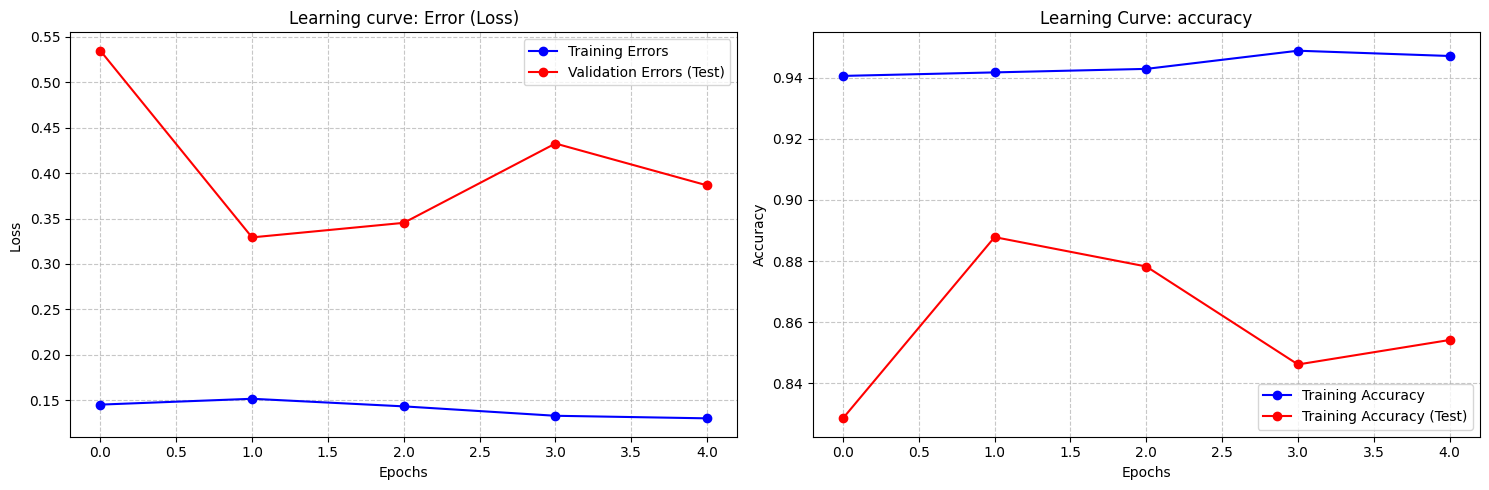

In [ ]:
import matplotlib.pyplot as plt

# Criando uma figura com 2 gráficos lado a lado (Loss e Acurácia)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Gráfico 1: Evolução do Erro (Loss) ---
ax1.plot(train_losses, label='Training Errors', color='blue', marker='o')
ax1.plot(test_losses, label='Validation Errors (Test)', color='red', marker='o')
ax1.set_title('Learning curve: Error (Loss)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss ')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Gráfico 2: Evolução da Acurácia ---
ax2.plot(train_accuracies, label='Training Accuracy', color='blue', marker='o')
ax2.plot(test_accuracies, label='Training Accuracy (Test)', color='red', marker='o')
ax2.set_title('Learning Curve: accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import importlib

# Isso força o Python a esquecer as alterações e carregar a biblioteca do zero
importlib.reload(plt)

# Importamos novamente só por garantia
import matplotlib.pyplot as plt

print("Biblioteca matplotlib destravada e pronta para desenhar!")

Biblioteca matplotlib destravada e pronta para desenhar!


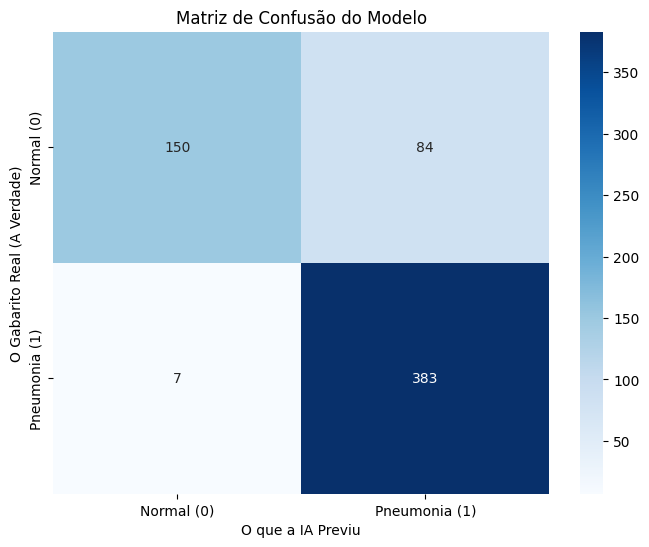

In [ ]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

predictions = []
template = []

model.eval()

with torch.no_grad():
  for inputs, labels in tests_loader:
    inputs = inputs.to(device)
    outputs = model(inputs)

    _, preds = torch.max(outputs, 1)

    predictions.extend(preds.cpu().numpy())
    template.extend(labels.numpy())

cm = confusion_matrix(template, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal (0)', 'Pneumonia (1)'],
                yticklabels=['Normal (0)', 'Pneumonia (1)'])

plt.title('Matriz de Confusão do Modelo')
plt.xlabel('O que a IA Previu')
plt.ylabel('O Gabarito Real (A Verdade)')
plt.show()

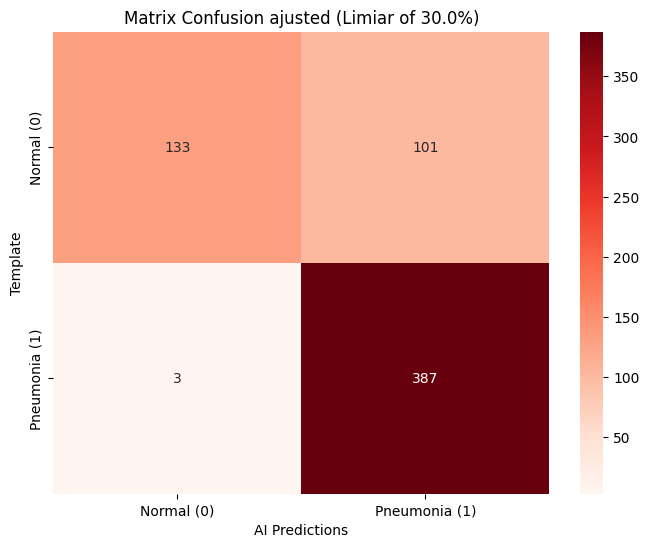

In [ ]:
import torch.nn.functional as F

NEW_LIM = 0.30

safe_pred = []
real_temp = []

model.eval()
with torch.no_grad():
  for inputs, labels in tests_loader:
    inputs = inputs.to(device)
    outputs = model(inputs)

    prob = F.softmax(outputs, dim=1)

    chance_pneumo = prob[:, 1]

    preds_ajusted = (chance_pneumo >= NEW_LIM).long()

    safe_pred.extend(preds_ajusted.cpu().numpy())
    real_temp.extend(labels.numpy())


cm_segura = confusion_matrix(real_temp, safe_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_segura, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal (0)', 'Pneumonia (1)'],
            yticklabels=['Normal (0)', 'Pneumonia (1)'])

plt.title(f'Matrix Confusion ajusted (Limiar of {NEW_LIM*100}%)')
plt.xlabel('AI Predictions')
plt.ylabel('Template')
plt.show()

# Pneumonia Detection from Chest X-Rays using Deep Learning

## Project Overview
This computer vision project focuses on the classification of chest X-ray images to assist in the clinical diagnosis of pneumonia. The primary objective is clinical safety; therefore, the model is calibrated to maximize Recall (Sensitivity), strictly minimizing False Negative predictions to ensure infected patients are not dismissed without treatment.

## Technologies and Frameworks
* **Language:** Python
* **Deep Learning Framework:** PyTorch, Torchvision
* **Architecture:** ResNet18 (Transfer Learning)
* **Data Manipulation and Visualization:** Matplotlib, Seaborn, Scikit-learn, NumPy

## Methodology

1. **Exploratory Data Analysis (EDA):** Analyzed the pixel brightness distribution across the dataset to mathematically validate the opacity differences between normal and infected lungs.
2. **Preprocessing and Data Augmentation:** Applied standardized resizing (224x224), ImageNet-based normalization, and random rotations to the training set to mitigate overfitting.
3. **Transfer Learning:** Implemented a pre-trained ResNet18 architecture. The convolutional base (feature extractors) was frozen to optimize GPU processing time, while the final dense layer (Fully Connected) was replaced and trained specifically for this binary classification task.
4. **Optimization:** Utilized the Adam optimizer and CrossEntropyLoss function.

## Results and Clinical Threshold Tuning

In medical diagnostics, a False Negative (classifying an infected patient as healthy) carries significantly more risk than a False Positive.

Due to natural dataset imbalance, the baseline model output an unacceptable rate of False Negatives (180 cases). To align the model with healthcare safety standards, a threshold tuning procedure was applied. The decision boundary was lowered from the default `0.50` to `0.30`.

**Final Metrics (Threshold = 0.30):**
* **Global Accuracy:** 83.33%
* **Recall / Sensitivity:** 99.23%
* **Specificity:** 56.83%
* **False Negatives:** Reduced from 180 to 3 cases.

This calibration demonstrates the model's viability as a highly sensitive triage tool for clinical environments.
